In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import sys 
sys.path.append(r'C:\Users\Tom\github\portfolio-V1\Tickers')
from valid_tickers import VALID_TICKERS

## 1) Model du CAPM:  

$$E(R_i) = R_f + \beta_{i}(E(R_m)-R_f)$$
$$\beta_{i} = \dfrac{Cov(R_i;R_m)}{Var(R_m)}$$

Où:  
$R_f$: taux sans risque (ex: obligation d'état, bon du trésor)  
$R_m$: représente le rendement de l'ensemble du marché (ou d'un indice de marché représentatif)  
$\beta$: rémuneration structuelle  




In [25]:
# calcule du beta ainsi que des parametres : 
def Cov(X, Y):
    return np.sum((X - np.mean(X)) * (Y - np.mean(Y))) / (len(X) - 1)
def Var(Y):
    return np.sum((Y - np.mean(Y)) ** 2) / (len(Y) - 1)
def Beta(X, Y):
    return Cov(X, Y) / Var(Y)



In [26]:
pf = yf.download(["AAPL", "^GSPC"], start='2020-01-01')['Close'].pct_change().dropna()
n = len(pf["AAPL"])
pf_beta = Beta(pf["AAPL"], pf["^GSPC"])
print("Beta de Apple par rapport à l'indice SP500 : ", round(pf_beta,2))


C:\Users\Tom\AppData\Local\Temp\ipykernel_12284\1377984995.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf = yf.download(["AAPL", "^GSPC"], start='2020-01-01')['Close'].pct_change().dropna()
[*********************100%***********************]  2 of 2 completed

Beta de Apple par rapport à l'indice SP500 :  1.19


$R^2$:Coefficient de détermination  
Le $R²$ mesure la proportion de la variance expliquée par le modèle.
$$
R^2 = \frac{SCR}{SCT} = 1 - \frac{SCE}{SCT}
$$

Où :
- $\text{SCR} = \sum (\hat{Y}_i - \bar{Y})^2$ (somme des carrés expliquée)
- $\text{SCE} = \sum (Y_i - \hat{Y}_i)^2$ (somme des carrés des erreurs)
- $\text{SCT} = \sum (Y_i - \bar{Y})^2$ (somme des carrés totale)


60.52 % des variation de apple s'explique par le sp500


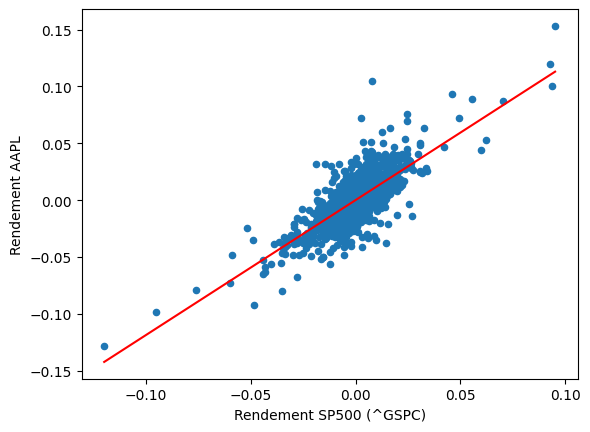

In [27]:
pf.plot.scatter(x='^GSPC', y='AAPL')
x_line = np.linspace(pf['^GSPC'].min(), pf['^GSPC'].max(), 100)
y_line = pf_beta * x_line
plt.plot(x_line, y_line, color='red', label='Ligne de régression')
plt.xlabel('Rendement SP500 (^GSPC)')
plt.ylabel('Rendement AAPL') 

### calcule de R^2 pour expliquer les variations de l'actif par rapport au marché 
alpha = pf["AAPL"].mean() - pf_beta * pf["^GSPC"].mean()

pf['appl_pred'] = alpha + pf_beta * pf["^GSPC"]
pf['erreur'] = pf["AAPL"] - pf["appl_pred"]

R_square = 1 - ( pf['erreur'].var() / pf['AAPL'].var())

print(f"{round(R_square * 100,2)} % des variation de apple s'explique par le sp500")


calcule de $E(R_m)$ avec la Prime de risque historique + taux sans risque  

$E(R_m) = R_f + prime\ de\ risque\ historique $  

avec :  
$prime\ de\ risque\ historique\ (ERP) = \dfrac{1}{T} \Sigma (R_{m,t} - R_{f,t}) $  

Comme on va faire un pf a valeur usa je pense que je vais prendre une obligation du tresort a 10 ans américaine pour ça.  
$R_f$ = US 10 Year Treasury Note Yield


In [28]:
sp500 = yf.download("^GSPC", start = "2000-01-01",interval= '1mo')['Close']
us10Y = yf.download("^TNX", start="2000-01-01",interval= '1mo')['Close']

## passage des données en annuel car yfinance ne le fait pas... 
sp500_yearly = sp500.resample('YE').last()
us10_yearly = us10Y.resample('YE').mean()

sp500_returns = sp500_yearly.pct_change().dropna() * 100 

sp500_returns.head()

data = pd.concat([sp500_returns,us10_yearly], axis=1).dropna()
data.head(10)

ERP = (np.mean(data["^GSPC"] - data["^TNX"]))

print(f'la prime de risque historique est de {round(ERP,2)} % ')

R_f = data['^TNX'].iloc[-1]

E_Rm = round(R_f + ERP,2) 

print(f'L\'esperence du marché est de {E_Rm} % ')

C:\Users\Tom\AppData\Local\Temp\ipykernel_12284\2152054142.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start = "2000-01-01",interval= '1mo')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Tom\AppData\Local\Temp\ipykernel_12284\2152054142.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  us10Y = yf.download("^TNX", start="2000-01-01",interval= '1mo')['Close']
[*********************100%***********************]  1 of 1 completed

la prime de risque historique est de 4.34 % 
L'esperence du marché est de 8.73 % 


In [29]:
E_Ri = round(R_f + pf_beta * (E_Rm - R_f),2)

print(f'L\'esperence de gain de l\'action Apple est de {E_Ri} % ')

L'esperence de gain de l'action Apple est de 9.55 % 


In [30]:
recap = pd.DataFrame({
    "esperance de l'action": [E_Ri],
    "R^2": [round(R_square *100,2)],
    "beta": [round(pf_beta,2)]
}, index= ["Apple"])

recap



,esperance de l'action,R^2,beta
Apple,9.55,60.52,1.19


A) Nous allons passer a une liste de 420 actions déjà filtré par claude pour faciliter la tache de recherche.  

In [31]:
actifs= yf.download(VALID_TICKERS, start='2020-01-01')['Close'].pct_change().dropna()
sprdm = yf.download("^GSPC", start='2020-01-01')['Close'].pct_change().dropna()

C:\Users\Tom\AppData\Local\Temp\ipykernel_12284\61890411.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  actifs= yf.download(VALID_TICKERS, start='2020-01-01')['Close'].pct_change().dropna()
[*********************100%***********************]  420 of 420 completed
C:\Users\Tom\AppData\Local\Temp\ipykernel_12284\61890411.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  actifs= yf.download(VALID_TICKERS, start='2020-01-01')['Close'].pct_change().dropna()
C:\Users\Tom\AppData\Local\Temp\ipykernel_12284\61890411.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sprdm = yf.download("^GSPC", start='2020-01-01')['Close'].pct_change().dropna()
[*********************100%***********************]  1 of 1 completed


In [ ]:
data2 = pd.concat([sprdm, actifs], axis= 1).dropna()
betas = ({})